In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102775_ outlier_removal(4th).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Mounted at /content/drive
Dataset loaded: (1025, 13)


,cholesterol,max_heart_rate,thalassemia,chest_pain_type,st_depression,num_major_vessels,exercise_angina,resting_bp,age,st_slope,sex,resting_ecg,heart_disease
0,-0.659332,0.821321,1.089852,-0.915755,-0.060888,1.209221,-0.712287,-0.377636,-0.268437,0.995433,0.661504,0.891255,0
1,-0.833861,0.255968,1.089852,-0.915755,1.727137,-0.731971,1.403928,0.479107,-0.158157,-2.243675,0.661504,-1.004049,0
2,-1.396233,-1.048692,1.089852,-0.915755,1.301417,-0.731971,1.403928,0.764688,1.716595,-2.243675,0.661504,0.891255,0
3,-0.833861,0.516900,1.089852,-0.915755,-0.912329,0.238625,-0.712287,0.936037,0.724079,0.995433,0.661504,0.891255,0
4,0.930822,-1.874977,-0.522122,-0.915755,0.705408,1.694519,-0.712287,0.364875,0.834359,-0.624121,-1.511706,0.891255,0


In [2]:
# Data Transformation

from scipy.stats import skew

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('heart_disease')

# Filter numeric columns with more than 1 unique value
num_cols_filtered = [c for c in num_cols if df[c].nunique() > 1]

# Skewness check
skew_vals = df[num_cols_filtered].apply(lambda x: skew(x))
print("Skewness values:\n", skew_vals)

# Apply log1p
df_trans = df.copy()
for col in num_cols_filtered:
    if abs(skew_vals[col]) > 0.75 and (df_trans[col] >= 0).all():
        df_trans[col] = np.log1p(df_trans[col])
        print(f"Applied log1p to {col}")

Skewness values:
 cholesterol          0.343310
max_heart_rate      -0.474164
thalassemia         -0.374586
chest_pain_type      0.528680
st_depression        1.017811
num_major_vessels    0.863461
exercise_angina      0.691641
resting_bp           0.401695
age                 -0.248502
st_slope            -0.478433
sex                 -0.850202
resting_ecg          0.180176
dtype: float64


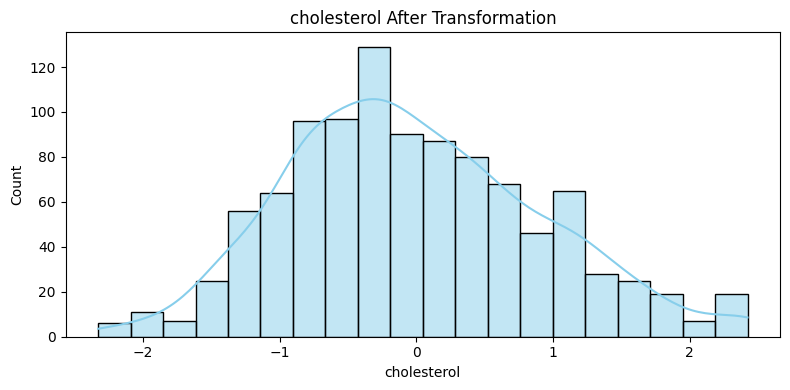

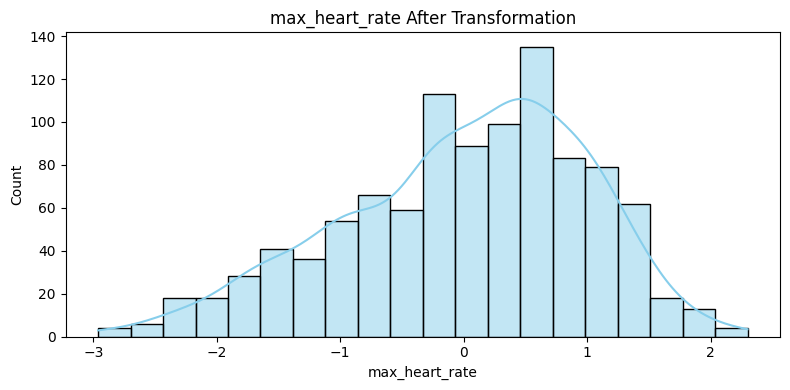

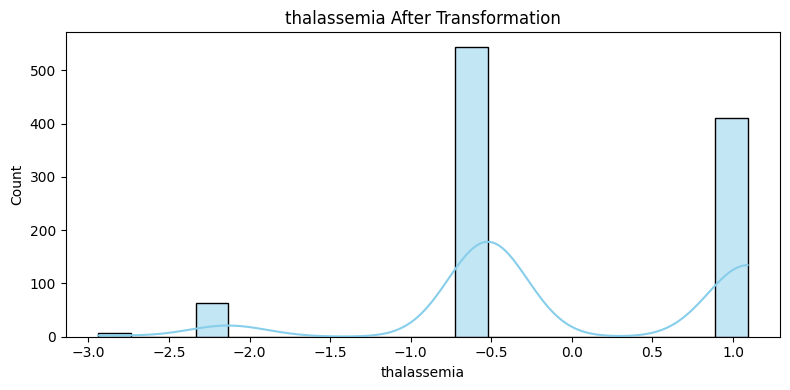

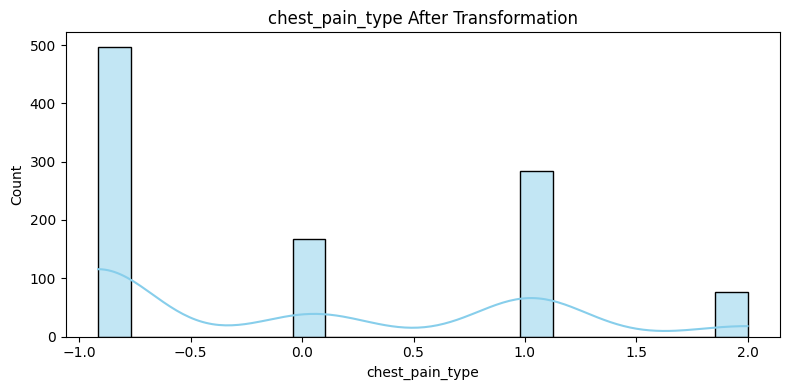

In [3]:
# Visualization
for col in num_cols[:4]:  # show first 4 to keep plots manageable
    fig, ax = plt.subplots(figsize=(8, 4))

    # After transform
    sns.histplot(df_trans[col], bins=20, kde=True, color="skyblue", ax=ax)
    ax.set_title(f"{col} After Transformation")

    plt.tight_layout()
    plt.show()

In [4]:
# Define save folder
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/data_transformation")
os.makedirs(SAVE_FOLDER, exist_ok=True)

#  Save plots
plot_path = os.path.join(SAVE_FOLDER, f"{col}_log_transform.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved plot: {plot_path}")
plt.close(fig)

Saved plot: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/data_transformation/chest_pain_type_log_transform.png


In [5]:
# Save updated dataset
PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102697_transformed(5th).csv")
df_trans.to_csv(PROC_PATH, index=False)
print("Transformed dataset saved at:", PROC_PATH)

Transformed dataset saved at: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102697_transformed(5th).csv
